# Current version : 10.D (2025-07-23)

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import clear_output
from datetime import datetime
import pickle
from datetime import datetime
import math
import scanpy as sc
from adjustText import adjust_text

pd.options.display.max_rows = 2000

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects


# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[ '#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [5]:
from module.misc import sample_name_import

name_dir = "circa-SD"
# name_dir = "all-samples"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


In [20]:
dir_notebook = '../notebook'
# dir_notebook = 'D:\Jupyter_notebook\Xenium_jupyter_notebook'


In [21]:
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')

In [ ]:
df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
df.shape

from module.xenium_preprocessing import add_annotations

df = add_annotations(adata, df)

In [266]:
df = pd.read_parquet(f'{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet')

In [ ]:
df[df['cell_type_final']=="Microglia"].groupby(['run','region_automap_name'])['cell_type_final'].value_counts().to_csv('data/microglia_dsitrib.csv')

In [ ]:
df.groupby('cell_type_final')['Bdnf'].mean().sort_values()

# List of lists

In [9]:
### Extract common phase
cell_list_under = ['SMC', 'Sncg_Gaba', 'STR_Gaba', 'COAa_PAA_MEA_Glut', 'OB_STR_CTX_IMN', 'MEA_Glut', 'L5_NP_CTX_Glut',
              'PAL_STR_Gaba_Chol', 'Vip_Gaba', 'Lamp5_Gaba', 'CLA_EPd_CTX_Glut', 'STR_PAL_Gaba', 'L6b_CTX_Glut',
                'Sst_Gaba', 'VLMC', 'PVH_Glut', 'ABC', 'AHN_Glut', 'SCH_Gaba', 'L5_ET_CTX_Glut', 'Choroid', 'Pericyte',
                  'LHA_Glut', 'Pvalb_Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2_3_IT_PIR_ENTl_Glut', 'L6_CT_CTX_Glut',
              'Endothelial', 'STR_D1_Gaba', 'L4_5_IT_CTX_Glut', 'Oligodendrocyte', 'STR_D2_Gaba', 'L6_IT_CTX_Glut', 'Astro_TE']
len(cell_list_under)

cell_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'COAa PAA MEA Glut', 'OB STR CTX IMN', 'MEA Glut', 'L5 NP CTX Glut',
              'PAL STR Gaba Chol', 'Vip Gaba', 'Lamp5 Gaba', 'CLA EPd CTX Glut', 'STR PAL Gaba', 'L6b CTX Glut',
                'Sst Gaba', 'VLMC', 'PVH Glut', 'ABC', 'AHN Glut', 'SCH Gaba', 'L5 ET CTX Glut', 'Choroid', 'Pericyte',
                  'LHA Glut', 'Pvalb Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2 3 IT PIR ENTl Glut', 'L6 CT CTX Glut',
              'Endothelial', 'STR D1 Gaba', 'L4 5 IT CTX Glut', 'Oligodendrocyte', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
               'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
                 'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
                   'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
                     'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
                       'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
                         'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
                           'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
                             'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
                               'Astro TE', 'OPC', 'Oligodendrocyte']


# Cycling genes

In [ ]:
import pandas as pd

In [ ]:
df_circa2 = pd.read_excel('../R/Results/2025-07-22_SD1_region/Summary/2025-07-22_SD1_cyc_siggene_analysis.xlsx', sheet_name = 'sig_cyl_gene')
df_circa4 = pd.read_excel('../R/Results/2025-07-22_circa4_region/Summary/2025-07-22_circa4_cyc_siggene_analysis.xlsx', sheet_name = 'sig_cyl_gene')

In [ ]:
circa4_gene = set(df_circa4['CycID'])
circa2_gene = set(df_circa2['CycID'])

In [ ]:
common_genes = circa4_gene.intersection(circa2_gene)

In [ ]:
len(common_genes), len(circa4_gene),len(circa2_gene)

In [ ]:
# library
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
venn2(subsets = (1449, 846, 560), set_labels = ('IGM', 'Salk'))
plt.show()


## Polar plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': ['Arntl', 'Clock', 'Cry1', 'Cry2','Npas2', 'Nr1d1', 'Per2', 'Per3','Rorc',
                            'Arntl','Clock','Cry1','Nr1d1','Per1','Per2','Per3','Rorc'
                            ],
                    'Phase': [1.00, 8.38, 15.31, 12.89, 22.56, 8.96,15.30,13.06,16.54,
                              1.00, 3.15, 16.75, 9.02, 11.92, 16.23, 14.17, 17.06
                            ]
                    })

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

ax.set_yticks(range(1, len(gene_order) + 1))
ax.set_yticklabels(gene_order)
ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left", title='Gene')

plt.tight_layout()
plt.show()

## Cell type spe polar

In [ ]:
import pandas as pd

dir_sum = '../R/Results/2025-06-25_circa4_celltype/Summary'

df = pd.read_excel(f'{dir_sum}/2025-06-25_circa4_cyc_siggene_by_celltype.xlsx', sheet_name=None, usecols=['CycID', 'meta2d_phase'])

In [ ]:
clockgenelist=['Arntl', 'Clock', 'Cry1', 'Cry2', 'Npas2', 'Nr1d1', 'Per1', 'Per2', 'Per3', 'Rora', 'Rorb', 'Rorc']
dataset = pd.DataFrame()
for key in df.keys():
    subdf = df[key].filter(['CycID', 'meta2d_phase'], axis=1)
    subdf = subdf[subdf['CycID'].isin(clockgenelist)]
    dataset = pd.concat([dataset, subdf])

In [ ]:
all_celltype_CG = dict(zip(dataset['CycID'], dataset['meta2d_phase']))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

## Histo polar plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
run_namdate_NS = "2025-08-08_circa4"
run_namdate_SD = "2025-08-09_SD1"
run_type = 'celltype'

dir_sum_NS = f'../R/Results/{run_namdate_NS}_{run_type}/Summary'
dir_sum_SD = f'../R/Results/{run_namdate_SD}_{run_type}/Summary'


df_all_NS = pd.read_excel(f'{dir_sum_NS}/{run_namdate_NS}_cyc_siggene_analysis.xlsx', sheet_name=None)
df_all_SD = pd.read_excel(f'{dir_sum_SD}/{run_namdate_SD}_cyc_siggene_analysis.xlsx', sheet_name=None)


# cycling_summary = pd.read_csv(f'{dir_sum}/{run_namdate}_cycling_gene_count_by_celltype.csv', index_col='cycling_gene_count')

In [ ]:
common_regions = set(df_all_NS.keys()).intersection(df_all_SD.keys())

for idx, celltype in enumerate(common_regions):
# for idx, celltype in enumerate(["Astro TE"]):
    # Data preparation
    df_NS = pd.DataFrame(data=zip(df_all_NS[celltype]['CycID'], df_all_NS[celltype]['meta2d_phase']))
    df_NS.columns = ['Gene','Phase']
    df_NS['Radians'] = df_NS['Phase'] / 24 * 2 * np.pi

    df_SD = pd.DataFrame(data=zip(df_all_SD[celltype]['CycID'], df_all_SD[celltype]['meta2d_phase']))
    df_SD.columns = ['Gene','Phase']
    df_SD['Radians'] = df_SD['Phase'] / 24 * 2 * np.pi

    # Plot
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.grid(True)

    ax.hist(df_NS['Radians'], bins = 24, alpha = 0.75, label = "NS")
    ax.hist(df_SD['Radians'], bins = 24, alpha = 0.75, label = "SD")

    ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

    plt.title(f'Genes Phase in {celltype}')
    plt.legend()
    plt.savefig(f'Gallery/{today}/polarplot/polar_gene_{celltype}.svg')
    plt.show()
    plt.close()


### Histo polar in region/gene panel

In [ ]:
import pandas as pd
from module.misc import genes_list

gene_list = genes_list('mitochondria')
region = 'SCH'
df_all = pd.read_excel(f'../R/Results/2025-08-11_circa4_celltype_and_region/Summary/2025-08-11_circa4_cyc_siggene_analysis.xlsx', sheet_name=region)

# # Data preparation
# df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
# df.columns = ['Gene','Phase']
# df = df[df['Gene'].isin(gene_list)]
# df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# # Plot
# plt.figure(figsize=(6,6))
# ax = plt.subplot(111, polar=True)
# ax.set_theta_direction(-1)
# ax.set_theta_offset(np.pi / 2.0)
# ax.grid(True)

# ax.hist(df['Radians'], bins = 24,
#         #  color = 'green'
#          )

# ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
# ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

# plt.title(f'Genes Phase in {region}')
# # plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from module.misc import genes_list

region = 'SCH'
df_all = pd.read_excel(f'data/SCH_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')
gene_list = genes_list('mitochondria')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

## Phase comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
run_namdate_1 = "2025-08-08_circa4"
run_namdate_2 = "2025-08-09_SD1"
run_type = 'celltype'
cell_type_plot = 'SCH Gaba'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

df_all_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)
df_all_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)

In [ ]:
from module.misc import genes_list

gene_list_plot = genes_list("clock")

dataset_NS = pd.DataFrame()

subdf_all_NS = df_all_NS.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_NS = subdf_all_NS[subdf_all_NS['CycID'].isin(gene_list_plot)]
dataset_NS = pd.concat([dataset_NS, subdf_all_NS])

dataset_SD = pd.DataFrame()
subdf_all_SD = df_all_SD.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_SD = subdf_all_SD[subdf_all_SD['CycID'].isin(gene_list_plot)]
dataset_SD = pd.concat([dataset_SD, subdf_all_SD])

In [ ]:
data = pd.DataFrame(index=gene_list_plot)

In [ ]:
all_celltype_NS = dict(zip(dataset_NS['CycID'], dataset_NS['meta2d_phase']))
all_celltype_SD = dict(zip(dataset_SD['CycID'], dataset_SD['meta2d_phase']))

In [ ]:
data['NS'] = data.index.map(all_celltype_NS)
data['SD'] = data.index.map(all_celltype_SD)
# data.dropna(inplace= True)
data['Gene'] = data.index
data['Diff'] = data['NS'] - data['SD']
data = data.sort_values(by='NS')

In [ ]:

data['NS2'] = data['NS']
data['SD2'] = data['SD']

# for n in range(len(data)):
#     if data.iloc[n,data.columns.get_loc("Diff")] > 12:
#         if data.iloc[n,data.columns.get_loc("NS")] < data.iloc[n,data.columns.get_loc("SD")]:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")] + 24
#         else:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
#     else:
#         data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]
#         data.iloc[n,data.columns.get_loc("SD")] = data.iloc[n,data.columns.get_loc("SD")]
thres = 12

for n in range(len(data)):
    if (abs(data.iloc[n,data.columns.get_loc("Diff")]) >= thres):
        if (data.iloc[n,data.columns.get_loc("SD")] > data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]-24
        elif (data.iloc[n,data.columns.get_loc("SD")] < data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
    else:
        data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]
        data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]

# data = data.sort_values(by="Diff", ascending=False)
data = data.sort_index()

In [ ]:
data

In [ ]:
# Convert phase to radians for polar plot
data['Radians_NS'] = data['NS'] / 24 * 2 * np.pi
data['Radians_SD'] = data['SD'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data.index
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data.index.map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

# Plot
plt.figure(figsize=(5,5))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data.index == gene]
    ax.scatter(subset['Radians_NS'], subset['Radius'], label=gene, color=gene_colors[gene], s=40, edgecolors='black')
    ax.scatter(subset['Radians_SD'], subset['Radius'], color=gene_colors[gene], alpha = 0.5, s=40)

ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])
ax.set_ylabel(ylabel=None)
plt.title('Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
# Color palette
import seaborn as sns
gene_order = data.index
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

In [ ]:
# data = data[0:20]

In [ ]:
plt.figure(figsize=(3,4))
ax =ax = plt.subplot()

for n in range(len(data)):
    ax.hlines(y=n, xmin=data.iloc[n,data.columns.get_loc("NS2")], xmax=data.iloc[n,data.columns.get_loc("SD2")], linestyles='dashed', color = 'black')
    ax.scatter(x=data.iloc[n,data.columns.get_loc("NS2")],y=n,
               color = data.iloc[n,data.columns.get_loc("Color")],
                 edgecolors='black', label = data.index.values[n])
    ax.scatter(x=data.iloc[n,data.columns.get_loc("SD2")], y=n, color = data.iloc[n,data.columns.get_loc("Color")])
ax.set_xlim(0,24)
ax.set_ylim(-0.25, len(data)-0.75)
ax.set_xticks([0,4,8,12,16,20,24])
ax.set_xlabel('ZT')
ax.set_yticks(ticks = range(len(data)),labels = data['Gene'])
ax.vlines(x = [0,12,24], ymin=0, ymax=len(data), color = 'darkgrey', linestyles='dashed')
ax.invert_yaxis()
plt.tight_layout()

# plt.legend()

## Barplot

In [ ]:
df_gen_NS = pd.read_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv', index_col="Celltype")
df_gen_SD = pd.read_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv', index_col="Celltype")

In [ ]:
df_gen_NS.to_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv')
df_gen_SD.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

In [ ]:
run_namdate_1 = "2025-08-08_circa4"
run_namdate_2 = "2025-08-09_SD1"
run_type = 'celltype'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

cycling_summary_1 = pd.read_csv(f'{dir_sum_1}/{run_namdate_1}_cycling_gene_per_group.csv', index_col='celltype')
cycling_summary_2 = pd.read_csv(f'{dir_sum_2}/{run_namdate_2}_cycling_gene_per_group.csv', index_col='celltype')

In [ ]:
NS_dict = dict(zip(cycling_summary_1.index,cycling_summary_1['cycling_gene_count']))
SD_dict = dict(zip(cycling_summary_2.index,cycling_summary_2['cycling_gene_count']))

df_gen_NS['Cycling_pval'] = df_gen_NS.index.map(NS_dict)
df_gen_SD['Cycling_pval'] = df_gen_SD.index.map(SD_dict)

In [ ]:
df_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])
df_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])


common = {}
sum_com = {}
common_cells = set(df_NS.keys()).intersection(set(df_SD.keys()))

for key in common_cells:
    # df_NS[key] = df_NS[key][df_NS[key]['meta2d_BH.Q']>=0.05]
    # df_SD[key] = df_SD[key][df_SD[key]['meta2d_BH.Q']>=0.05]
    common[key] = df_NS[key][df_NS[key]['CycID'].isin(df_SD[key]['CycID'])]
    sum_com[key] = len(common[key])

sum_com_df = pd.DataFrame({'Gene': sum_com.keys(),
                    'Common': sum_com.values()})
sum_com_df.index = sum_com_df['Gene']

In [ ]:
sum_com_dict = dict(zip(sum_com_df['Gene'],sum_com_df['Common']))
df_gen_NS['Common_pval'] = df_gen_NS.index.map(sum_com_dict)
df_gen_SD['Common_pval'] = df_gen_SD.index.map(sum_com_dict)


In [ ]:
df_NS_BH_nb = [len(df_NS[key]) for key in df_NS.keys()]
ddf_NS_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_NS_BH_nb}, index = df_NS.keys())

df_SD_BH_nb = [len(df_SD[key]) for key in df_SD.keys()]
ddf_SD_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_SD_BH_nb}, index = df_SD.keys())

# NS_BH_dict = dict(zip(ddf_NS_BH_nb.index, ddf_NS_BH_nb['Expressed_genes']))
# df_gen_NS['Cycling_BH'] = df_gen_NS.index.map(NS_BH_dict)

# SD_BH_dict = dict(zip(ddf_SD_BH_nb.index, ddf_SD_BH_nb['Expressed_genes']))
# df_gen_SD['Cycling_BH'] = df_gen_SD.index.map(SD_BH_dict)

In [ ]:
cycling_summary_1 = cycling_summary_1[cycling_summary_1.index.isin(cycling_summary_2.index)].sort_values(by='cycling_gene_count')
cycling_summary_2 = cycling_summary_2[cycling_summary_2.index.isin(cycling_summary_1.index)]

In [ ]:
len(cycling_summary_1), len(cycling_summary_2)

In [ ]:
df_gen_NS.sort_values(by='Common_pval',inplace=True)
df_gen_NS.drop('CEA Gaba',axis=0, inplace=True)
# df_gen_NS.dropna(axis=0, inplace= True)
# df_gen_SD.dropna(axis=0, inplace= True)

In [ ]:
len(df_gen_NS), len(df_gen_SD)

In [ ]:
which_has_more_CG = {}

for gene in df_gen_NS.index:
    if df_gen_NS['Cycling_pval'][gene] < df_gen_SD['Cycling_pval'][gene]:
        which_has_more_CG[gene] = 0
    else:
        which_has_more_CG[gene] = 1

which_has_more_CG.keys()


In [ ]:
fig, ax = plt.subplots(figsize = (5,8))
# ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Count'], label = 'Expressed', color = 'None', edgecolor ='black')
# ax.barh(y = df_gen_SD.index, width = df_gen_SD['Count'], color = 'None', edgecolor = 'black')

ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Cycling_pval'], edgecolor = 'black', label = 'Cycling NS', align = "center")
ax.barh(y = df_gen_SD.index, width= df_gen_SD['Cycling_pval'], edgecolor = 'black', label = 'Cycling SD', align = "center")
ax.barh(y = df_gen_NS.index, width=df_gen_NS['Common_pval'], label = 'Common', color = 'black', align = "center")
ax.barh(y = df_gen_SD.index, width=-df_gen_SD['Common_pval'], color = 'black', align = "center")
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS))
ax.set_xlim(-2000,2000)
ax.grid(axis="x")
ax.set_axisbelow(b=True)
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep')

for n, gene in enumerate(which_has_more_CG.keys()):
    if which_has_more_CG[gene] > 0:
        ax.text(x = -df_gen_NS['Cycling_pval'][gene]-75, y = n-0.5, s = '#', weight = 'bold', ha = "center")
    else:
        ax.text(x = df_gen_SD['Cycling_pval'][gene]+75, y = n-0.5, s = '#',weight = 'bold', ha = "center")


plt.savefig(f'Gallery/{today}/Cycling_genes_overview.svg', dpi=300, format ="svg", transparent = True)

In [ ]:
which_has_more_CG

In [ ]:
order_list =[
        "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC",
        "Ependymal", "OB STR CTX IMN","OPC","Astro TE", "SCH Gaba","PVH Glut","AHN Glut","PAL STR Gaba Chol","MEA Glut","LHA Glut",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","L2 3 PIR ENTl Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "DG Glut","STR PAL Gaba","STR D1 Gaba","STR D2 Gaba",]


cycling_summary_1_sort = cycling_summary_1.reindex(order_list)
cycling_summary_1_sort.dropna(axis=0, inplace=True)
cycling_summary_1_sort = cycling_summary_1_sort.reindex(sorted(cycling_summary_1_sort.columns), axis=1)
cycling_summary_1_sort.head(2)

In [ ]:
df_gen_NS_sort =df_gen_NS.reindex(order_list)
df_gen_SD_sort = df_gen_SD.reindex(order_list)
df_gen_NS_sort.dropna(axis=0, inplace= True)
df_gen_SD_sort.dropna(axis=0, inplace= True)
cycling_summary_2_sort = cycling_summary_2.reindex(order_list)
cycling_summary_2_sort.dropna(axis=0, inplace=True)

In [ ]:
len(df_gen_NS_sort),len(df_gen_SD_sort),len(cycling_summary_1_sort),len(cycling_summary_2_sort)

In [ ]:
fig, ax = plt.subplots(figsize = (5,8))
# ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Count'], label = 'Expressed', color = 'None', edgecolor ='black')
# ax.barh(y = df_gen_SD.index, width = df_gen_SD['Count'], color = 'None', edgecolor = 'black')
ax.barh(y = df_gen_NS_sort.index, width = -df_gen_NS_sort['Cycling_pval'], edgecolor = 'black', label = 'Cycling NS')
ax.barh(y = df_gen_SD_sort.index, width= df_gen_SD_sort['Cycling_pval'], edgecolor = 'black', label = 'Cycling SD')
ax.barh(y = df_gen_NS_sort.index, width=df_gen_NS_sort['Common_pval'], label = 'Common', color = 'black')
ax.barh(y = df_gen_SD_sort.index, width=-df_gen_SD_sort['Common_pval'], color = 'black')
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS_sort), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS_sort))
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep')
plt.savefig(f'Gallery/{today}/Cycling_genes_overview_dendro.svg',dpi=300)

## Cycling genes correlation

In [ ]:
run_namdate = "2025-07-21_circa4"
run_type = 'celltype'

dir_sum = f'../R/Results/{run_namdate}_{run_type}/Summary'

df_all = pd.read_excel(f'{dir_sum}/{run_namdate}_cyc_siggene_analysis.xlsx', sheet_name=None)

In [ ]:
from module.misc import genes_list

gens = genes_list('panel_5k')

df_genes = pd.DataFrame(data={"Gene" : gens}, index= gens)


for key in df_all.keys():
    df_genes[key] = np.zeros(len(df_genes))

    for gene in df_all[key]['CycID'].unique():
        df_genes.loc[gene,key] +=1



In [ ]:
df_genes.drop('Gene',axis=1, inplace=True)

In [ ]:
# order_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'PAL STR Gaba Chol',
#        'L2 3 PIR ENTl Glut', 'MEA Glut', 'OB STR CTX IMN', 'L5 NP CTX Glut',
#        'COAa PAA MEA Glut', 'Vip Gaba', 'Lamp5 Gaba', 'DG Glut', 'ABC',
#        'STR PAL Gaba', 'PVH Glut', 'L6b CTX Glut', 'AHN Glut', 'SCH Gaba',
#        'Sst Gaba', 'VLMC', 'L5 ET CTX Glut', 'Pericyte', 'LHA Glut',
#        'Ependymal', 'Pvalb Gaba', 'Microglia', 'OPC', 'L2 3 IT PIR ENTl Glut',
#        'STR D1 Gaba', 'L6 CT CTX Glut', 'Endothelial', 'Oligodendrocyte',
#        'L4 5 IT CTX Glut', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

order_list =[
        "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC",
        "Ependymal", "OB STR CTX IMN","OPC","Astro TE", "SCH Gaba","PVH Glut","AHN Glut","PAL STR Gaba Chol","MEA Glut","LHA Glut",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","L2 3 PIR ENTl Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "DG Glut","STR PAL Gaba","STR D1 Gaba","STR D2 Gaba",]

df_genes_sort = df_genes.loc[:, order_list]

In [ ]:
df_corr = df_genes_sort.corr(method='kendall')

In [ ]:
df_corr.min().min()

In [ ]:
import seaborn as sns

sns.clustermap(df_corr, cmap = 'Blues', vmin=0,vmax=1,
                col_cluster=False,row_cluster=False, cbar = False, cbar_pos=None,figsize=(12, 12),
                )
plt.title('Correlation of cycling genes in NS')
plt.savefig(f'Gallery/{today}/NS_corr_cyclinggenes_ordernbcycgenes.svg',dpi=300)

## Phase Comparison plotting

### Summary table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from module.misc import genes_list
import numpy as np
import math

cg_list = genes_list('clock')

In [ ]:
dataframe_cg_cycling = pd.DataFrame(data = {"Gene" : cg_list,
                                            "Expressed": np.zeros(len(cg_list)),
                                            "NS_Cyc" : np.zeros(len(cg_list)),
                                            "SD_Cyc" : np.zeros(len(cg_list)),
                                            "Common_Cyc" : np.zeros(len(cg_list)),
                                            "Same_phase" : np.zeros(len(cg_list)),
                                            "Same Amplitude" :np.zeros(len(cg_list)),
                                            "Same Mesor" : np.zeros(len(cg_list))
                                             },
                                              index = cg_list)
dataframe_cg_cycling.sample()

In [ ]:
cell_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'COAa PAA MEA Glut', 'OB STR CTX IMN', 'MEA Glut', 'L5 NP CTX Glut',
              'PAL STR Gaba Chol', 'Vip Gaba', 'Lamp5 Gaba', 'CLA EPd CTX Glut', 'STR PAL Gaba', 'L6b CTX Glut',
                'Sst Gaba', 'VLMC', 'PVH Glut', 'ABC', 'AHN Glut', 'SCH Gaba', 'L5 ET CTX Glut', 'Choroid', 'Pericyte',
                  'LHA Glut', 'Pvalb Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2 3 IT PIR ENTl Glut', 'L6 CT CTX Glut',
              'Endothelial', 'STR D1 Gaba', 'L4 5 IT CTX Glut', 'Oligodendrocyte', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

In [ ]:
### Extract expression
for cell in cell_list:
    df_expressed_NS = pd.read_csv(f'../R/data/gene_list_SD1/{cell}.csv')
    gene_exp_NS = set(df_expressed_NS[df_expressed_NS['0'].isin(cg_list)]['0'])
    df_expressed_SD = pd.read_csv(f'../R/data/gene_list_circa4/{cell}.csv')
    gene_exp_SD = set(df_expressed_SD[df_expressed_SD['0'].isin(cg_list)]['0'])
    common_exp =  gene_exp_NS.intersection(gene_exp_SD)

    if len(common_exp) > 0:
        for gene in common_exp:
            dataframe_cg_cycling.loc[gene, "Expressed"] +=1

In [ ]:
### Extract common cycling

df_cycling_NS = pd.read_excel(f'../R/Results/2025-08-08_circa4_celltype/Summary/2025-08-08_circa4_cyc_siggene_analysis.xlsx', sheet_name = None)
df_cycling_SD = pd.read_excel(f'../R/Results/2025-08-09_SD1_celltype/Summary/2025-08-09_SD1_cyc_siggene_analysis.xlsx', sheet_name = None)

for cell in cell_list:
    gene_cyc_NS = set(df_cycling_NS[cell][df_cycling_NS[cell]['CycID'].isin(cg_list)]['CycID'])
    if len(gene_cyc_NS) > 0:
        for gene in gene_cyc_NS:
            dataframe_cg_cycling.loc[gene, "NS_Cyc"] +=1
    gene_cyc_SD = set(df_cycling_SD[cell][df_cycling_SD[cell]['CycID'].isin(cg_list)]['CycID'])
    if len(gene_cyc_SD) > 0:
        for gene in gene_cyc_SD:
            dataframe_cg_cycling.loc[gene, "SD_Cyc"] +=1
    common_cyc = gene_cyc_NS.intersection(gene_cyc_SD)
    if len(common_cyc) > 0:
        for gene in common_cyc:
            dataframe_cg_cycling.loc[gene, "Common_Cyc"] +=1

In [ ]:
### Extract common phase
cell_list_under = ['SMC', 'Sncg_Gaba', 'STR_Gaba', 'COAa_PAA_MEA_Glut', 'OB_STR_CTX_IMN', 'MEA_Glut', 'L5_NP_CTX_Glut',
              'PAL_STR_Gaba_Chol', 'Vip_Gaba', 'Lamp5_Gaba', 'CLA_EPd_CTX_Glut', 'STR_PAL_Gaba', 'L6b_CTX_Glut',
                'Sst_Gaba', 'VLMC', 'PVH_Glut', 'ABC', 'AHN_Glut', 'SCH_Gaba', 'L5_ET_CTX_Glut', 'Choroid', 'Pericyte',
                  'LHA_Glut', 'Pvalb_Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2_3_IT_PIR_ENTl_Glut', 'L6_CT_CTX_Glut',
              'Endothelial', 'STR_D1_Gaba', 'L4_5_IT_CTX_Glut', 'Oligodendrocyte', 'STR_D2_Gaba', 'L6_IT_CTX_Glut', 'Astro_TE']
len(cell_list_under)

In [ ]:
for cell in cell_list_under:
    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for difference in phase'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same_phase"] +=1

    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for amplitude difference'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same Amplitude"] +=1

    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for mesor difference'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same Mesor"] +=1

In [ ]:
dataframe_cg_cycling.sort_values(by='Common_Cyc')

In [ ]:
dataframe_cg_cycling.sort_values(by='Same_phase',inplace=True, ascending=False)

In [ ]:
w1 = dataframe_cg_cycling['Expressed'][0:25] - dataframe_cg_cycling['Common_Cyc'][0:25] 
w2 = dataframe_cg_cycling['Common_Cyc'][0:25] -  dataframe_cg_cycling["Same_phase"][0:25]
w3 = dataframe_cg_cycling["Same_phase"][0:25]

_, ax = plt.subplots(1,2, figsize = (4,6), sharey= True)

ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w1, left = 0, label = "Expressed NS/SD", color = "#3f488aff", edgecolor ="black")
ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w2, left = w1, label = "Cycling NS/SD", color= "#f79a00ff", edgecolor ="black")
ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w3, left = w1+w2, label = "In phase", color = "#81a5bfff", edgecolor ="black")
ax[1].set_xticks(ticks = [0,12,24,36])
ax[1].set_xlim(0,36)
ax[1].set_xlabel('Number of celltypes')
ax[1].legend(loc = 'best', bbox_to_anchor = (0.99,0.5))
                                          

ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['NS_Cyc'][0:25], height=0.4, align="edge", edgecolor ="black",label = "Cycling NS")
ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['SD_Cyc'][0:25], height=-0.4, align="edge", edgecolor ="black", label = "Cycling SD")
ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['Expressed'][0:25], height=-0.8, align="center",fill = None, edgecolor ="black", label = "Expressed")

ax[0].legend(loc = 'upper left', bbox_to_anchor = (2.2,1))
ax[0].set_xticks(ticks = [0,12,24,36])
ax[0].set_xlim(0,36)
ax[0].set_xlabel('Number of celltypes')

plt.ylim(-0.5,24.5)

# plt.savefig(f"Gallery/{today}/Summary_cycling_phase_compare_top-inphase.svg", format='svg',transparent = True)

### Create database

#### Celltype

In [10]:
dict_all_cycling = {}

for idx, cell in enumerate(cell_list_under):
    df_cyc_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
    df_cyc_NS.index = df_cyc_NS['CycID']
    df_cyc_filter_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
    df_cyc_filter_NS.index = df_cyc_filter_NS['CycID']
    df_cyc_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
    df_cyc_SD.index = df_cyc_SD['CycID']
    df_cyc_filter_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
    df_cyc_filter_SD.index = df_cyc_filter_SD['CycID']
    df_circacompare = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    df_circacompare.index = df_circacompare['gene']

    df_DEG = pd.read_excel('../notebook/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=cell_list[idx])
    df_DEG.index = df_DEG['names']
    # df_DEG = df_DEG[df_DEG['group'] == "SD1"]

    df_DEG_filter = df_DEG[(df_DEG['pvals_adj'] < 0.05)
                                 & (df_DEG['pct_nz_group'] > 0.0)
                                 & (df_DEG['pct_nz_reference'] > 0)
                                 & (abs(df_DEG['logfoldchanges']) > 0.26)
                                 & (df_DEG['mean_count'] >= 0.01)
                                 & (df_DEG['group'] == "SD1")
                                 ]


    dict_all_cycling[cell] = {"NS_cyc" : df_cyc_NS,
                              "NS_cyc_filter" : df_cyc_filter_NS, 
                              "SD_cyc" : df_cyc_SD,
                              "SD_cyc_filter" : df_cyc_filter_SD,
                              "CircaCompare" : df_circacompare,
                              "DEG" : df_DEG,
                              "DEG_filter" : df_DEG_filter}


#### Celltype in regions

In [ ]:
import os
import pandas as pd

regions_DEG = ['AHN','AMY','AV','CM','CTX','HIPP', 'HY','LD','LHA','LH','LSX', 'MEA', 'MH','NLOT','PVH','PVT','RE', 'RT ZI','SCH','SMT','STR','TH','TRS','VLMC','VM' 'MD', 'VP','WM']
regions_Cyc = ["AHN", "AMY", "CTX", "LHA", "PVH","SCH", "STR"]

dict_all_cellinreg = {}



directory_DEG = '../notebook/analysis/circa-SD/foldchanges/celltype_in_region/'
directory_NS = '../R/Results/2025-08-11_SD1_celltype_and_region/Raw/'
directory_SF = '../R/Results/2025-08-11_circa4_celltype_and_region/Raw/'


all_regions_NS = os.listdir(directory_NS)
all_regions_NS =  [region for region in all_regions_NS if region.split('_')[-1] == 'analysis.xlsx' ]

all_regions_SF = os.listdir(directory_SF)
all_regions_SF =  [region for region in all_regions_SF if region.split('_')[-1] == 'analysis.xlsx' ]

all_regions_DEG = os.listdir(directory_DEG)
all_regions_DEG =  [region for region in all_regions_DEG if region.split('_')[-1] == 'DEG.xlsx' ]

region = 'SCH'

dict_all_cellinreg[region] = {}

for cell in cell_list_under:
    dict_all_cellinreg[region][cell] = {}
    if f'{cell}_in_{region}_cyc_analysis.xlsx' in all_regions_NS:
        dict_all_cellinreg[region][cell]['NS_cyc_filter'] = pd.read_excel(f'{directory_NS}/{cell}_in_{region}_cyc_analysis.xlsx', sheet_name = 'sig_cyl_gene')
        dict_all_cellinreg[region][cell]['NS_cyc'] = pd.read_excel(f'{directory_NS}/{cell}_in_{region}_cyc_analysis.xlsx', sheet_name = 'meta')
    if f'{cell}_in_{region}_cyc_analysis.xlsx' in all_regions_SF:
        dict_all_cellinreg[region][cell]['SF_cyc_filter'] = pd.read_excel(f'{directory_SF}/{cell}_in_{region}_cyc_analysis.xlsx', sheet_name = 'sig_cyl_gene')
        dict_all_cellinreg[region][cell]['SF_cyc'] = pd.read_excel(f'{directory_SF}/{cell}_in_{region}_cyc_analysis.xlsx', sheet_name = 'meta')
    
    


In [ ]:
dict_all_cellinreg['SCH']['Astro_TE'].keys()

In [ ]:
all_regions_NS

In [ ]:
# for idx, cell in enumerate(cell_list_under):
#     df_cyc_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
#     df_cyc_NS.index = df_cyc_NS['CycID']
#     df_cyc_filter_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
#     df_cyc_filter_NS.index = df_cyc_filter_NS['CycID']
#     df_cyc_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
#     df_cyc_SD.index = df_cyc_SD['CycID']
#     df_cyc_filter_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
#     df_cyc_filter_SD.index = df_cyc_filter_SD['CycID']
#     df_circacompare = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
#     df_circacompare.index = df_circacompare['gene']

#     df_DEG = pd.read_excel('../notebook/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=cell_list[idx])
#     df_DEG.index = df_DEG['names']
#     # df_DEG = df_DEG[df_DEG['group'] == "SD1"]

#     df_DEG_filter = df_DEG[(df_DEG['pvals_adj'] < 0.05)
#                                  & (df_DEG['pct_nz_group'] > 0.0)
#                                  & (df_DEG['pct_nz_reference'] > 0)
#                                  & (abs(df_DEG['logfoldchanges']) > 0.26)
#                                  & (df_DEG['mean_count'] >= 0.01)
#                                  & (df_DEG['group'] == "SD1")
#                                  ]


#     dict_all_cellinreg[cell] = {"NS_cyc" : df_cyc_NS,
#                               "NS_cyc_filter" : df_cyc_filter_NS, 
#                               "SD_cyc" : df_cyc_SD,
#                               "SD_cyc_filter" : df_cyc_filter_SD,
#                               "CircaCompare" : df_circacompare,
#                               "DEG" : df_DEG,
#                               "DEG_filter" : df_DEG_filter}


In [ ]:
df = pd.read_excel('../R/Results/2025-08-11_SD1_celltype_and_region/')

#### Save and Load Database

In [ ]:
with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "wb") as handle:
    pickle.dump(dict_all_cycling, handle, protocol=-1)


In [11]:
with open(f"data/cycling_genes_database.pickle", "wb") as handle:
    pickle.dump(dict_all_cycling, handle, protocol=-1)

In [ ]:
import pickle
with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

### Plot cycling gene phase comparison

In [ ]:
cg_to_plot = 'Srebf2'

In [ ]:

df_temp = pd.DataFrame(data = {"Celltype" : cell_list_under,
                               "CircaCompare_pval" : np.zeros(len(cell_list_under)),
                               "CircaCompare_NS_Phase": np.zeros(len(cell_list_under)),
                               "CircaCompare_SD_Phase" : np.zeros(len(cell_list_under)),
                               "CircaCompare_phase_diff" : np.zeros(len(cell_list_under)),
                               "Cyc_NS_filt_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_SD_filt_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_NS_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_SD_phase" : np.zeros(len(cell_list_under)),
                               }, index = cell_list_under)

for cell in cell_list_under:
    if len(dict_all_cycling[cell]['CircaCompare'][dict_all_cycling[cell]['CircaCompare']['gene']==cg_to_plot]) != 0:
        df_temp.loc[cell, "CircaCompare_pval"] = dict_all_cycling[cell]['CircaCompare']['P-value for difference in phase'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_NS_Phase"] = dict_all_cycling[cell]['CircaCompare']['circa4 peak time hours'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_SD_Phase"] = dict_all_cycling[cell]['CircaCompare']['SD1 peak time hours'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_phase_diff"] = dict_all_cycling[cell]['CircaCompare']["Phase difference estimate"][cg_to_plot]
    else:
        df_temp.loc[cell, "CircaCompare_pval"] = 1
        df_temp.loc[cell, "CircaCompare_NS_Phase"] = df_temp.loc[cell, "CircaCompare_SD_Phase"] = -1
        df_temp.loc[cell, "CircaCompare_phase_diff"] = 0
    
    if len(dict_all_cycling[cell]['NS_cyc_filter'][dict_all_cycling[cell]['NS_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_NS_filt_phase"] = dict_all_cycling[cell]['NS_cyc_filter']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_NS_filt_phase"] = -1

    if len(dict_all_cycling[cell]['SD_cyc_filter'][dict_all_cycling[cell]['SD_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_SD_filt_phase"] = dict_all_cycling[cell]['SD_cyc_filter']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_SD_filt_phase"] = -1

    if len(dict_all_cycling[cell]['SD_cyc_filter'][dict_all_cycling[cell]['SD_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_SD_phase"] = dict_all_cycling[cell]['SD_cyc']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_SD_phase"] = -1

    if len(dict_all_cycling[cell]['NS_cyc_filter'][dict_all_cycling[cell]['NS_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_NS_phase"] = dict_all_cycling[cell]['NS_cyc']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_NS_phase"] = -1


df_temp['Circa_diff'] = df_temp['CircaCompare_NS_Phase'] -  df_temp['CircaCompare_SD_Phase']

In [ ]:
plt.figure(figsize=(4,8))
plt.xticks([0,4,8,12,16,20,24])
plt.xlim(0,24)
plt.scatter(y = df_temp['Celltype'], x =df_temp['CircaCompare_NS_Phase'], color = "green", alpha = 0.8, edgecolor="black", label ="NS")
plt.scatter(y = df_temp['Celltype'], x =df_temp['CircaCompare_SD_Phase'], color = "red", alpha = 0.8, edgecolor="black", marker="v", label ="SD")

for cell in df_temp['Celltype']:
    if (0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (df_temp.loc[cell,'CircaCompare_NS_Phase'] < df_temp.loc[cell,'CircaCompare_SD_Phase']) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) != abs(math.trunc(df_temp.loc[cell,'Circa_diff']))):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'CircaCompare_NS_Phase']+24, color = "green", alpha = 0.8, edgecolor="black", label ="NS")
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmax = df_temp.loc[cell,'CircaCompare_NS_Phase']+24, xmin = df_temp.loc[cell,'CircaCompare_SD_Phase'], color = 'black', linestyles="dashed")
        x_av = ((df_temp['CircaCompare_NS_Phase'][cell]+24) + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')
        plt.xlim(0,36)
        plt.xticks([0,4,8,12,16,20,24,28,32,36])
    elif (0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (df_temp.loc[cell,'CircaCompare_NS_Phase'] > df_temp.loc[cell,'CircaCompare_SD_Phase']) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) != abs(math.trunc(df_temp.loc[cell,'Circa_diff']))):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'CircaCompare_SD_Phase']+24, color = "red", marker="v", alpha = 0.8, edgecolor="black", label ="NS")
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmax = df_temp.loc[cell,'CircaCompare_SD_Phase']+24, xmin = df_temp.loc[cell,'CircaCompare_NS_Phase'], color = 'black', linestyles="dashed")
        x_av = ((df_temp['CircaCompare_NS_Phase'][cell]+24) + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')
        plt.xlim(0,36)
        plt.xticks([0,4,8,12,16,20,24,28,32,36])
    elif((0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) == abs(math.trunc(df_temp.loc[cell,'Circa_diff'])))):
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmin = df_temp.loc[cell,'CircaCompare_NS_Phase'], xmax = df_temp.loc[cell,'CircaCompare_SD_Phase'], color = 'black', linestyles="dashed")
        x_av = (df_temp['CircaCompare_NS_Phase'][cell] + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')

for cell in df_temp['Celltype']:
    if (df_temp.loc[cell,'CircaCompare_pval'] == 1):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'Cyc_NS_filt_phase'], color = "green", alpha = 0.5)
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'Cyc_SD_filt_phase'], color = "red", alpha = 0.5, marker="v")




plt.ylim(-0.5,36)
plt.vlines(x=[12,24,36],ymin=0,ymax=36, color = "lightgrey", linestyles="dashed")
plt.title(cg_to_plot)
# plt.legend()
# plt.yticks(ticks = range(0,36), label=cell_list_under)
plt.savefig(f'Gallery/{today}/CG_all-celltype_{cg_to_plot}.svg', format = 'svg',transparent = True)

## GO analysis

### Pre-process

In [ ]:
## Download ontologies from http://geneontology.org/ontology/go-basic.obo
## Download associations from ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz

from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

# obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")



In [ ]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated mouse genes".format(NS=nspc, N=len(id2gos)))

In [ ]:
from module.genes_ncbi_mouse_proteincoding import GENEID2NT as GeneID2nt_mouse

print(len(GeneID2nt_mouse))

In [ ]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method



In [ ]:
## Get all the go items including those appears multiple times

GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [ ]:
## Build mapping dictionaries between gene id and gene symbols

id_mapper = {}

for key_2 in GeneID2nt_mouse:
    id_mapper[GeneID2nt_mouse[key_2].Symbol] = GeneID2nt_mouse[key_2].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()} 

In [ ]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

### Process

#### Cycling genes

In [ ]:
### Alternative Cycling genes
target_genes_NS = NS_cyc
target_genes_NS = [id_mapper[gene] for gene in target_genes_NS if gene in id_mapper]

target_genes_SD = SD_cyc
target_genes_SD = [id_mapper[gene] for gene in target_genes_SD if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_NS)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_NS = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_up = goeaobj.run_study(target_genes_SD)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_SD = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

df_go_NS.head(15), df_go_SD.head(15)

#### Alternative list of genes

In [ ]:
list_gen = ddf_table[ddf_table['ratio_UNASSIGNED']>0.5]['Unnamed: 0'].values
print(*list_gen)

In [ ]:
### Alternative list of genes
target_genes_list = list_gen
target_genes_list = [id_mapper[gene] for gene in target_genes_list if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of mouse protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_list)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_list = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])



df_go_list.head(15)

### GO plot

In [ ]:
df_go_down.head(5)
len(df_go_up)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

plt.figure(figsize=(4,6),dpi=300)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams["font.size"] = 10

if min(len(df_go_up), len(df_go_down)) > 7:
    n_g = 8
else:
    n_g = min(len(df_go_up), len(df_go_down))

up_labels = [s for s in df_go_up['term'][0:n_g]][::-1]
up_ngenes = [s for s in df_go_up['n_genes'][0:n_g]][::-1]
up_pvalues = [-np.log10(p) for p in df_go_up['p_corr'][0:n_g]][::-1]
up_ycor = [0.1*n for n in range(1,len(up_labels)+1)]

down_labels = [s for s in df_go_down['term'][0:n_g]][::-1]
down_ngenes = [s for s in df_go_down['n_genes'][0:n_g]][::-1]
down_pvalues = [-np.log10(p) for p in df_go_down['p_corr'][0:n_g]][::-1]
down_ycor = [0.1*n for n in range(len(down_labels)+1,len(down_labels)+len(up_labels)+1)]

#print(len(y_cor),len(labels),len(p_values))

plt.barh(up_ycor,up_pvalues,height=0.05, color = 'blue', label = 'Upregulated')

plt.barh(down_ycor,down_pvalues,height=0.05, color = 'red', label = 'Downregulated')

plt.yticks(up_ycor+down_ycor,[textwrap.fill(e,40) for e in up_labels+down_labels],fontsize=8)

for x,gene in enumerate(up_ngenes):
    plt.text(up_pvalues[x] + 0.5, up_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

for x,gene in enumerate(down_ngenes):
    plt.text(down_pvalues[x] + 0.5, down_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

#plt.yticks()
plt.xticks([0,3.0,6.0])
plt.xlabel('-log10(p_value)')
# plt.ylim(0,n_g)

plt.savefig(f'Gallery/{today}/GO_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')

# plt.savefig(f'Gallery/{today}/GO_{region_of_interest}_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')
plt.legend(markerscale=20, bbox_to_anchor=(1.02, 1), loc='lower left', borderaxespad=0)
plt.show()

In [ ]:
df_go_down

In [81]:
filename_ = 'plaque_up'

df = pd.read_csv(f'data/Metascape/{filename_}.csv')
df.sample(1)
len(df)

7

C:\Users\hcall\AppData\Local\Temp\ipykernel_8528\1560865300.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x=df['logP'], y=df['GO'], s=df['nb_gene']**2, cmap='viridis')


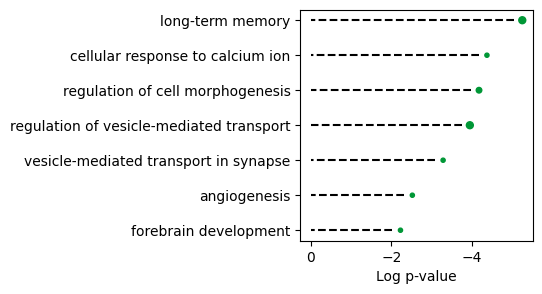

In [82]:
plt.figure(figsize=(3,4))
plt.scatter(x=df['logP'], y=df['GO'], s=df['nb_gene']**2, cmap='viridis')

for idx, go in enumerate(df['GO'].unique()):
    plt.hlines(y=df['GO'][idx], xmin=df['logP'][idx]+0.2, xmax=0, color = 'black', linestyle = 'dashed') 

plt.xlabel('Log p-value')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.savefig(f'Gallery/{today}/GO_{filename_}.svg', transparent= True, dpi=300)

# Upset plot

In [ ]:
from upsetplot import plot
from upsetplot import from_contents


In [ ]:
test_dict = {"Microglia": df_filter['Microglia']['names'].values,
             "Astro TE": df_filter['Astro TE']['names'].values,
             "Oligodendrocytes" : df_filter['Oligodendrocyte']['names'].values}

In [ ]:
celltype_inregion_DEG_filter.keys()

In [ ]:
from upsetplot import from_contents

common = from_contents(test_dict)

plot(common)  

# Circascore v2

In [ ]:
geno_dict = {"WT":0,
             "APP":1}
df_circa_temp['Genotype_num'] = df_circa_temp['Genotype'].map(geno_dict)

In [ ]:
import seaborn as sns
df_circa_temp['Genotype_num'] = df_circa_temp['Genotype_num'].astype(str)
num_clusters = len(df_circa_temp['Genotype_num'].astype(int).unique())
cmap_ = "viridis"
palette = sns.color_palette(cmap_, n_colors=num_clusters)
df_circa_temp['leiden_colors'] = df_circa_temp['Genotype_num'].astype(int).apply(lambda x: palette[x])


In [ ]:
import seaborn  as sns

sns.clustermap(df_plot, cmap = 'inferno', vmin=0,vmax=1, z_score=1,
                col_cluster=True,row_cluster=True, cbar = True, cbar_pos=None,figsize=(20, 40),
                dendrogram_ratio= 0.05,
                # row_colors=df_circa_temp['leiden_colors'],
                )

## run

In [1]:
import pickle

with open(f"data/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)


In [2]:
from module.misc import genes_list

clockgeneslist = genes_list('clock')

list_of_cells = dict_all_cycling.keys()

In [116]:
### Create dataframe for normalized gene expression

norm_exp_NS = {}
norm_exp_SF = {}

for gene in clockgeneslist:
    temp_NS = pd.DataFrame(index=list_of_cells)
    temp_SF = pd.DataFrame(index=list_of_cells)

    temp_NS['mean_count'] = 0.0
    temp_SF['mean_count'] = 0.0

    for cell in list_of_cells:
        temp_NS.loc[cell, 'mean_count'] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=='circa4'].loc[gene,'mean_count']
        temp_SF.loc[cell, 'mean_count'] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=='SD1'].loc[gene,'mean_count']
    
    norm_exp_NS[gene] = temp_NS
    norm_exp_SF[gene] = temp_SF

for gene in clockgeneslist:
    norm_exp_NS[gene]['normalized_count'] = norm_exp_NS[gene]['mean_count'] / max(norm_exp_NS[gene]['mean_count'])
    norm_exp_SF[gene]['normalized_count'] = norm_exp_SF[gene]['mean_count'] / max(norm_exp_SF[gene]['mean_count'])



In [117]:
circascore = pd.DataFrame(index=list_of_cells)
circascore['circascore_NS'] = 0.0
circascore['circascore_SF'] = 0.0

for cell in list_of_cells:
    temp_comb_NS = 0.0
    temp_comb_SF = 0.0

    for gene in clockgeneslist:
        prct_group = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=='circa4'].loc[gene, 'pct_nz_group']
        norm_mean_exp = norm_exp_NS[gene]['normalized_count'][cell]

        temp = (1+ prct_group) * (1 + norm_mean_exp)

        if len(set([gene]).intersection(set(dict_all_cycling[cell]['NS_cyc_filter']['CycID'].values))) == 1:
            temp = temp * 2 ### Factor depending on the number of celltype having this gene cycling ? 
        else:
            temp = temp
    
        temp_comb_NS += temp
    
    circascore.loc[cell, 'circascore_NS'] = temp_comb_NS.astype(float)

    for gene in clockgeneslist:
        prct_group = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=='SD1'].loc[gene, 'pct_nz_group']
        norm_mean_exp = norm_exp_SF[gene]['normalized_count'][cell]

        temp = (1 + prct_group) * (1 + norm_mean_exp)

        if len(set([gene]).intersection(set(dict_all_cycling[cell]['SD_cyc_filter']['CycID'].values))) == 1:
            temp = temp * 2 ### Factor depending on the number of celltype having this gene cycling ? 
        else:
            temp = temp
    
        temp_comb_SF += temp
    
    circascore.loc[cell, 'circascore_SF'] = temp_comb_SF.astype(float)


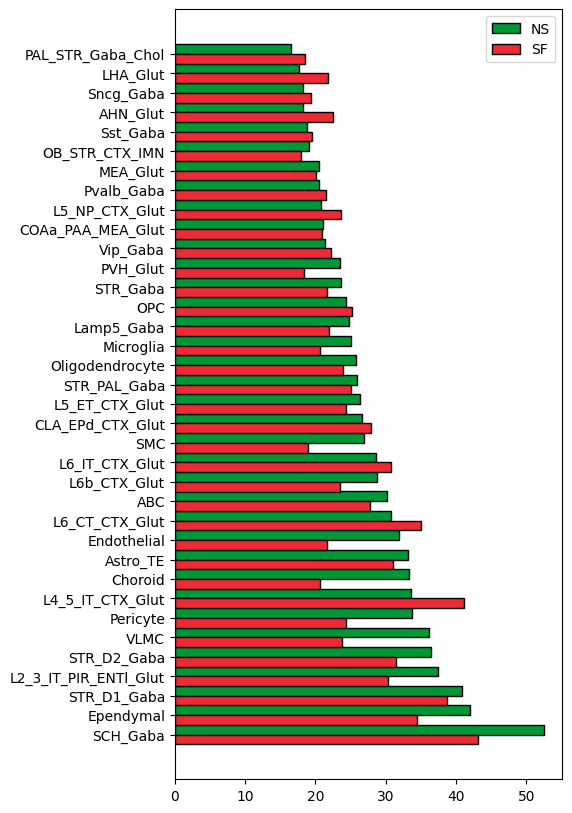

In [118]:
circascore.sort_values(by='circascore_NS', ascending = False, inplace = True)

plt.figure(figsize = (5,10))
plt.barh(circascore.index, circascore['circascore_NS'], height=0.5, edgecolor ='black', align = "edge", label = "NS" )
plt.barh(circascore.index, circascore['circascore_SF'], height=-0.5, edgecolor ='black', align = "edge", label = 'SF' )
plt.legend()
# plt.xscale('log')

In [119]:
circascore['Diff'] = circascore['circascore_SF'] - circascore['circascore_NS']

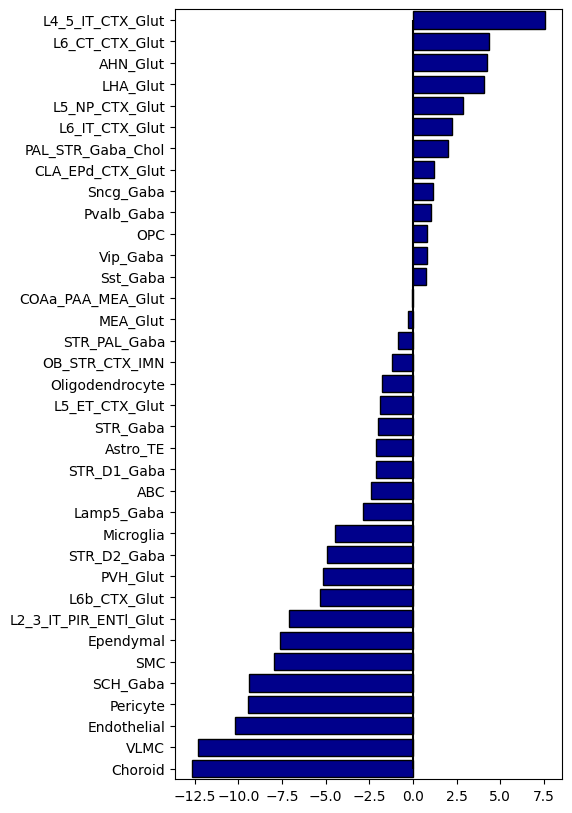

In [120]:
plt.figure(figsize = (5,10))

plt.barh(circascore.sort_values(by='Diff').index, circascore.sort_values(by='Diff')['Diff'], color= 'darkblue', edgecolor= 'black')
plt.ylim(-0.5, 35.5)
plt.vlines(x=0, ymin = 0, ymax = 35, color = 'black')

In [ ]:
### Find all celltypes where given gene is differently expressed

app_list = []
gene = 'Vip'

for cell in list_of_cells:
    if dict_all_cycling[cell]['DEG_filter']['names'].isin([gene]).sum() == 1:
        if dict_all_cycling[cell]['DEG_filter']['logfoldchanges'][gene] < 0:
            print(cell,'Down', dict_all_cycling[cell]['DEG_filter']['logfoldchanges'][gene])
        else:
            print(cell, "Up", dict_all_cycling[cell]['DEG_filter']['logfoldchanges'][gene])
        # print(cell)
        app_list.append(cell)

Lamp5_Gaba Down -0.5950267910957336
Sst_Gaba Down -0.6289082765579224
SCH_Gaba Up 0.5975269675254822
L5_ET_CTX_Glut Down -0.7159841656684875
Pvalb_Gaba Down -0.6776701807975769
OPC Down -0.5329518914222717
L2_3_IT_PIR_ENTl_Glut Down -0.3903080224990845
L4_5_IT_CTX_Glut Down -0.4191995859146118
L6_IT_CTX_Glut Down -0.299538254737854


In [ ]:
dict_all_cycling[cell]['DEG_filter']['logfoldchanges']['Arc'] 

In [35]:
dict_C2_NS = dict(zip(circascore['circascore_NS'].index,circascore['circascore_NS'].values))
dict_C2_SF = dict(zip(circascore['circascore_NS'].index,circascore['circascore_NS'].values))

In [37]:
adata_temp = adata[adata.obs['run']=='circa4']
adata_temp.obs['circascorev2'] = adata_temp.obs['cell_type_final'].map(dict_C2_NS)
dict_NS2 = dict(zip(adata_temp.obs['cell_id'],adata_temp.obs['circascorev2']))

adata_temp = adata[adata.obs['run']=='SD1']
adata_temp.obs['circascorev2'] = adata_temp.obs['cell_type_final'].map(dict_C2_SF)
dict_SF2 = dict(zip(adata_temp.obs['cell_id'],adata_temp.obs['circascorev2']))

/tmp/ipykernel_50331/4002116479.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_temp.obs['circascorev2'] = adata_temp.obs['cell_type_final'].map(dict_C2_NS)
/tmp/ipykernel_50331/4002116479.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_temp.obs['circascorev2'] = adata_temp.obs['cell_type_final'].map(dict_C2_SF)


In [38]:
dict_NS2.update(dict_SF2)

In [39]:
adata.obs['circascorev2'] = adata.obs['cell_id'].map(dict_NS2)

In [41]:
adata.obs[['cell_type_final','circascorev2']].sample(10)

,cell_type_final,circascorev2
circa4-IGM-ZT09_hbghblbg-1,ABC,30.141446
SD1-ZT05_cbelidgb-1,STR_D2_Gaba,33.989900
circa4-IGM-ZT09_efcbhecb-1,Astro_TE,32.685777
SD1-ZT05_dijholep-1,Astro_TE,32.685777
SD1-ZT17_fciebdbf-1,L5_ET_CTX_Glut,23.321755
circa4-IGM-ZT21_dmlbefel-1,Astro_TE,32.685777
SD1-ZT09_eghjcncl-1,RE_Glut,NaN
circa4-IGM-ZT05_bijmkmdi-1,L6_CT_CTX_Glut,28.883562
SD1-ZT01_ebilnnik-1,Endothelial,33.387090
circa4-IGM-ZT17_cggejimo-1,STR_D2_Gaba,33.989900


In [49]:
adata[(adata.obs['run']=='circa4')&(~adata.obs['circascorev2'].isna())].obs.groupby('region_automap_name')['circascorev2'].mean().sort_values()

/tmp/ipykernel_50331/2215508378.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata[(adata.obs['run']=='circa4')&(~adata.obs['circascorev2'].isna())].obs.groupby('region_automap_name')['circascorev2'].mean().sort_values()


region_automap_name
CTX          28.502424
LHA          28.707177
AHN          28.746879
AMY          29.107504
HIPP         29.495797
PVH          29.535953
RT ZI        29.695583
LSX          29.761201
WM           30.025930
LH           30.329319
VP           30.346025
PT           30.478233
BST          30.598051
SMT          30.699694
VM MD        30.744701
AV           30.848184
MH           30.874132
AD           30.900601
LD           30.994022
CM           31.166179
PVT          31.202620
RE           31.272509
STR          31.860833
VLMC         32.188273
Tanycyte     32.381842
Choroid      33.507549
Ependymal    35.337591
SCH          38.509565
Name: circascorev2, dtype: float64

In [75]:
adata_uno = adata[(adata.obs['sample'] == "circa4-IGM-ZT01")&(~adata.obs['circascorev2'].isna())]

In [79]:
adata_uno.obs['circascorev2'] = adata_uno.obs['circascorev2'].astype(int)

/tmp/ipykernel_50331/3766606918.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_uno.obs['circascorev2'] = adata_uno.obs['circascorev2'].astype(int)


In [113]:
palette

[(0.197297, 0.0384, 0.367535),
 (0.472328, 0.110547, 0.428334),
 (0.735683, 0.215906, 0.330245),
 (0.929644, 0.411479, 0.145367),
 (0.986175, 0.713153, 0.103863)]

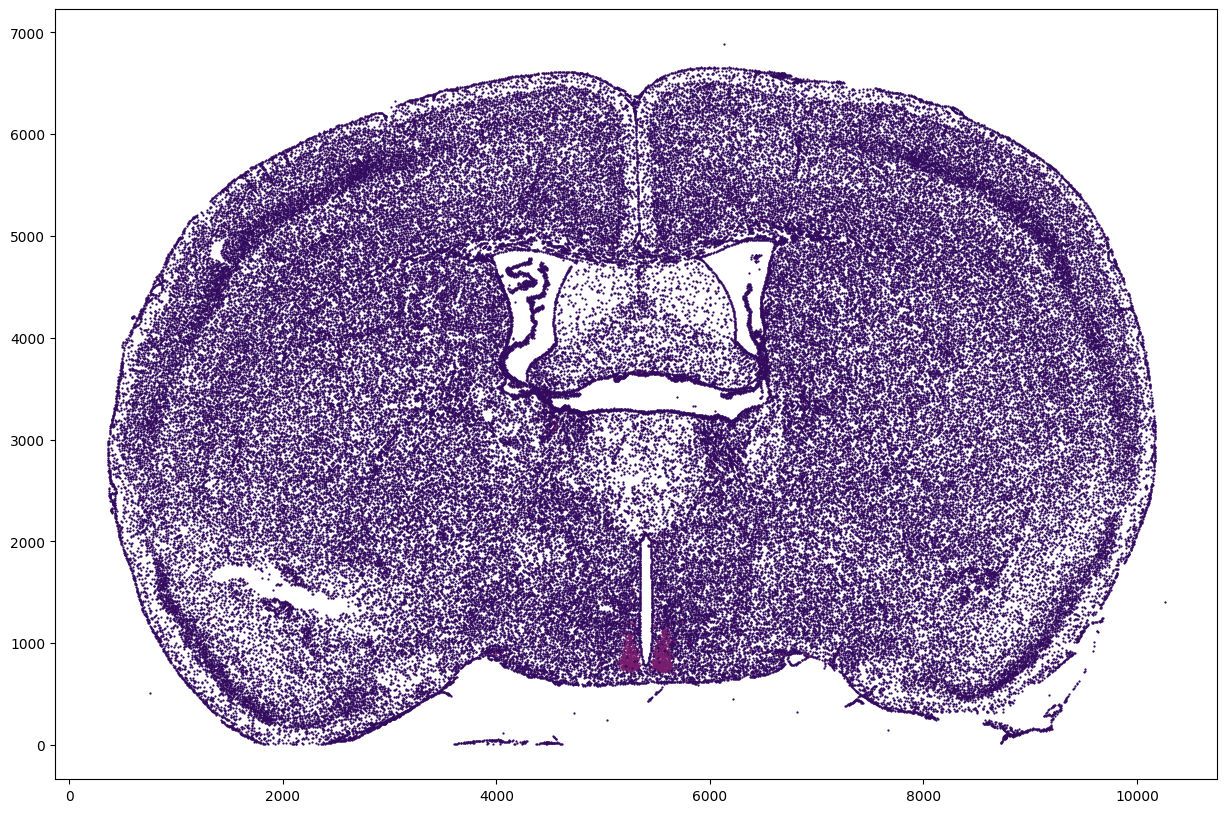

In [112]:
import seaborn as sns
### TODO: to integrate to module as single plot
# samples_ids = ['circa4-IGM-ZT05']
label_to_use = "cell_type_final"
cluster_to_use = "circascorev2"

### Generate a color palette for the clusters - to make color stay consistent across samples
num_clusters = len(adata_uno.obs[cluster_to_use].astype(int).unique())
palette = sns.color_palette("inferno", n_colors=5)
adata_uno.obs['leiden_colors'] = adata_uno.obs[cluster_to_use].astype(int).apply(lambda x: palette[x])

plt.figure(figsize=(15,10))
for idx, sample in enumerate(samples_ids):
    adata_sel = adata_uno[(adata_uno.obs['sample'] == sample)]
    cluster_to_map2 = adata_sel.obs[cluster_to_use].unique()
    for cluster_id in cluster_to_map2:
        cluster_data = adata_sel.obs[adata_sel.obs[cluster_to_use] == cluster_id]
        colors = cluster_data['leiden_colors'].unique()[0] ### for all clusters
        plt.scatter(cluster_data['x_centroid'], cluster_data['y_centroid'], marker = 'H', color=colors, s=0.5, label=cluster_data[label_to_use].unique()[0])
        # plt.title(f"Sample {sample}")
        # plt.xaxis.tick_params(labelbottom=False)
        # plt.yaxis.tick_params(labelleft=False)
        # plt.aspect('equal', adjustable='box')
# plt.xlim(4500,6000)
# # plt.ylim(500,2000)
# plt.legend()
# plt.savefig('plot/c4IGMFLL.png', dpi=300, format = "png", transparent = True)

# Test

In [ ]:
df_all = pd.read_excel(f'{dir_notebook}/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if "circa4" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][
            (df_all[key]['pct_nz_group']>0.05) &
          (df_all[key]['mean_count']>= 0.01)
          ]
    df_all[key].index = df_all[key]['names']

In [ ]:
import pandas as pd
import pickle

df = pd.read_pickle('data/cycling_genes_database.pickle')


In [ ]:
df_all[key].keys()

In [ ]:
keys = df_all.keys()
temp_set = set()

for key in keys:
    temp = df_all[key][(df_all[key]['mean_count']>0.01)
                       & (df_all[key]['mean_count']>0.05)].sort_values(by="mean_count")['names'].values
    temp_set.update(temp)

In [ ]:
len(temp_set)

In [ ]:
temp_set = list(temp_set)

In [ ]:
temp_set = pd.DataFrame(temp_set)
temp_set.to_csv('data/temp_set_expressed_genes.csv')

In [ ]:
4264/5006*100
# 742+4264


In [ ]:
from module.misc import genes_list
panel_5k = genes_list('panel_5k')

In [ ]:
panel = set(panel)
diff = temp_set.difference(panel)

In [ ]:
len(diff)

In [ ]:
panel.difference_update(temp_set)

In [ ]:
len(panel)

In [ ]:
not_exp = pd.DataFrame(panel)
not_exp.to_csv('data/not_exp.csv')

In [ ]:
df_all['Tanycyte'][(df_all['Tanycyte']['mean_count']>0.01)
                   & (df_all['Tanycyte']['pct_nz_group']>0.05)
                   & (df_all['Tanycyte']['group'] == "circa4")].shape

In [ ]:
keys = df_all.keys()
ddf = pd.DataFrame(index=list(panel))
ddf['count_SF'] = 0
ddf['count_NS'] = 0

for gene in panel_5k:
    count_NS = 0
    count_SF = 0
    for key in keys:
        if len(df_all[key][(df_all[key]["names"]==gene)
                           & (df_all[key]["mean_count"]>0.01)
                           & (df_all[key]["group"]== 'circa4')
                           & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            count_NS +=1
        if len(df_all[key][(df_all[key]["names"]==gene)
                & (df_all[key]["mean_count"]>0.01)
                & (df_all[key]["group"]== 'SD1')
                & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            count_SF +=1
    ddf.loc[gene, "count_NS"] = count_NS
    ddf.loc[gene, "count_SF"] = count_SF

In [ ]:
ddf['Diff'] = ddf['count_NS']- ddf['count_SF']

ddf.head(10),ddf.tail(10)

In [ ]:
# plt.scatter(x = ddf["count_NS"], y=ddf['count_SF'])
# plt.xlabel('NS')
# plt.ylabel('SF')
# for gene in ddf.index:
#     plt.text(x = ddf["count_NS"][gene], y=ddf['count_SF'][gene], s = gene)

# ddf.sort_values(by='count_SF', inplace = True)
# plt.figure(figsize=(15,10))
# plt.bar(x=ddf.index, height = ddf['count_NS'], label = "NS")
# plt.bar(x=ddf.index, height = ddf['count_SF'], label = "SF")
# plt.legend()

# ddf.sort_values(by='Diff', inplace = True)
# plt.figure(figsize=(15,10))
# plt.barh(y=ddf.index, width = ddf['Diff'], label = "Diff")

In [ ]:
ddf_n0 = ddf[ddf['count'] != 0]
ddf_n0['count'].value_counts()

In [ ]:
dddf = pd.DataFrame(index = ddf[ddf['count'] == 1].index)
dddf['celltype'] = "0"

for gene in ddf[ddf['count'] == 1].index:
    for key in keys:
        if len(df_all[key][(df_all[key]["names"]==gene) & (df_all[key]["mean_count"]>0.01)
                        & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            print(key)
            dddf.loc[gene,'celltype'] = key

In [ ]:
dddf['celltype'].value_counts()

In [ ]:
dddf.sort_values(by='celltype', inplace=True)
dddf

In [ ]:
df_all['PVH Glut'][df_all['PVH Glut']["names"]=="Opn3"]

In [ ]:
gene = "Camk2a"
keys = df_all.keys()
for key in keys:
    if len(df_all[key][(df_all[key]["names"]==gene)
                        & (df_all[key]["mean_count"]>0.01)
                        & (df_all[key]["group"] =="SD1")
                        & (df_all[key]["pct_nz_group"] > 0.05)]
                        # & (df_all[key]['pvals_adj']>0.05)
                        # & (df_all[key]['logfoldchanges'] > 0.26)
                        ) > 0:
        print(key)

In [ ]:
keys = df_all.keys()
ddf = pd.DataFrame(index=list(keys))
ddf['count_SF'] = 0
ddf['count_NS'] = 0
ddf['Common'] = 0
ddf['Diff'] = 0
all_set = set()
diff_set = set()
common_set = set()

for key in keys:
    set_NS = set(df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'circa4')]['names'])
    
    count_NS = len(set_NS)

    set_SF = set(df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'SD1')]['names'])

    count_SF = len(set_SF)

    common_set = set_NS.intersection(set_SF)

    if len(set_NS) > len(set_SF):
        diff_set = set_NS.difference(set_SF)
    else:
        diff_set = set_SF.difference(set_NS)

    all_set.update(set_NS, set_SF)

    ddf.loc[key, "count_NS"] = count_NS
    ddf.loc[key, "count_SF"] = count_SF
    ddf.loc[key, "Common"] = len(common_set)
    ddf.loc[key, "Diff"] = len(diff_set)

In [ ]:
len(df_all["Tanycyte"][(df_all["Tanycyte"]["mean_count"]>0.01) & (df_all["Tanycyte"]["group"]== 'circa4')]['names'])
# len(set_NS)

In [ ]:
df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'SD1')]['names']

In [ ]:
# ddf['Diff'] =ddf['count_NS']-ddf['count_SF']
ddf#.sort_values(by='Common',ascending=False)

In [ ]:
len(all_set)

In [ ]:
dddf = pd.DataFrame()

In [ ]:
ddf_n0 = ddf[ddf['count'] != 0]
ddf_n0['count'].value_counts()

In [ ]:
for key in df.keys():
    if len(df[key]['DEG_filter'][df[key]['DEG_filter']['names']=="Kif5a"]) > 0:
        print(key)

# Clock genes binary

In [8]:
import pickle
with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    df = pickle.load(handle)

In [5]:
from module.misc import genes_list

clockgenes = genes_list('clock')

In [6]:
clockgenes.sort()
clockgenes

['Arntl',
 'Clock',
 'Cry1',
 'Cry2',
 'Npas2',
 'Nr1d1',
 'Per1',
 'Per2',
 'Per3',
 'Rora',
 'Rorb',
 'Rorc']

In [11]:
ddf = pd.DataFrame(index=cell_list_under)


for key in df.keys():
    
    for gene in clockgenes:
        temp = 0
        if len(df[key]['NS_cyc_filter']['CycID'][df[key]['NS_cyc_filter']['CycID']==gene]) > 0:
            temp += 0.5

        if len(df[key]['SD_cyc_filter']['CycID'][df[key]['SD_cyc_filter']['CycID']==gene]) > 0:
            temp += 1

        ddf.loc[key, gene] = temp
    


In [127]:
ddf.reindex(cell_list_under)

NameError: name 'ddf' is not defined

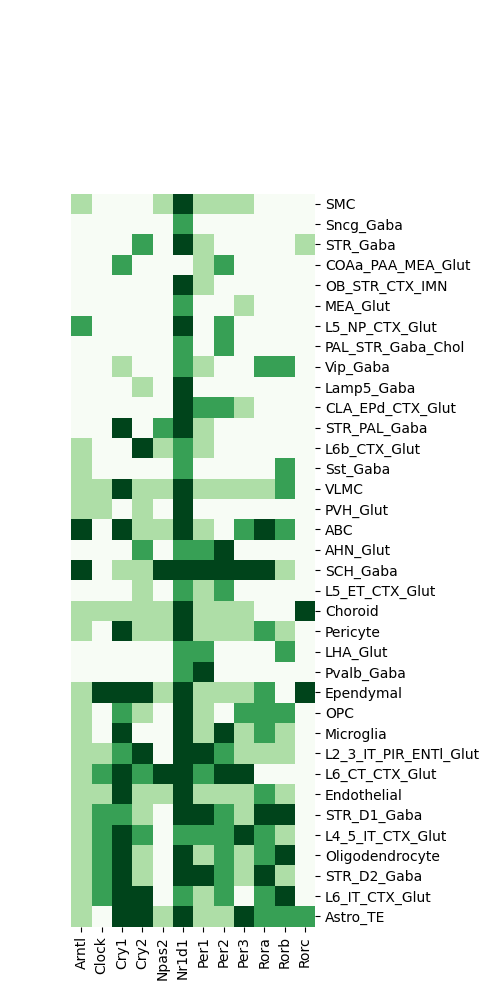

In [13]:
import seaborn as sns

sns.clustermap(ddf, cmap = 'Greens',
                col_cluster=False,row_cluster=False, cbar = False, cbar_pos=None,figsize=(5,10),
                )

In [ ]:
len(df['SCH_Gaba']['SD_cyc_filter']['CycID'][df['SCH_Gaba']['SD_cyc_filter']['CycID']=='Rorc'])

In [126]:
if 'leiden_colors' in adata.obs:
    adata.obs = adata.obs.drop(columns=['leiden_colors'])
adata.write_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz")

NameError: name 'clockgenelist' is not defined

In [219]:
dict_all_cycling[cell]['CircaCompare'].head()

,gene,Presence of rhythmicity (p-value) for circa4,Presence of rhythmicity (p-value) for SD1,circa4 mesor estimate,SD1 mesor estimate,Mesor difference estimate,P-value for mesor difference,circa4 amplitude estimate,SD1 amplitude estimate,Amplitude difference estimate,P-value for amplitude difference,circa4 peak time hours,SD1 peak time hours,Phase difference estimate,P-value for difference in phase,Shared period estimate
gene,,,,,,,,,,,,,,,,
A2m,A2m,1.342015e-02,1.961058e-10,0.051813,0.037508,-0.014305,7.709708e-04,0.014732,0.018769,0.004037,0.460997,1.382428,6.571918,5.189490,2.751027e-04,24
Aatf,Aatf,2.375442e-06,3.043325e-03,0.050180,0.043365,-0.006815,3.946934e-07,0.009477,0.002666,-0.006811,0.000080,4.847905,16.712587,11.864682,2.038238e-08,24
Abca1,Abca1,2.042561e-03,6.972247e-05,0.132695,0.129377,-0.003318,5.022253e-01,0.021982,0.019467,-0.002515,0.718415,4.142331,2.674321,-1.468010,2.606168e-01,24
Abca3,Abca3,8.632660e-08,1.784219e-03,0.192671,0.179829,-0.012842,1.145083e-02,0.039559,0.020204,-0.019355,0.007436,4.529532,2.753377,-1.776156,8.945485e-02,24
Abcb8,Abcb8,2.385441e-07,3.965956e-08,0.029613,0.025714,-0.003899,3.823413e-07,0.006117,0.005099,-0.001019,0.241759,5.015292,4.761547,-0.253745,6.692397e-01,24


/tmp/ipykernel_50331/679469359.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_ = max(df_amp['NS'][idx], df_amp['SF'][idx])


Text(0.5, 0, 'Normalized expression')

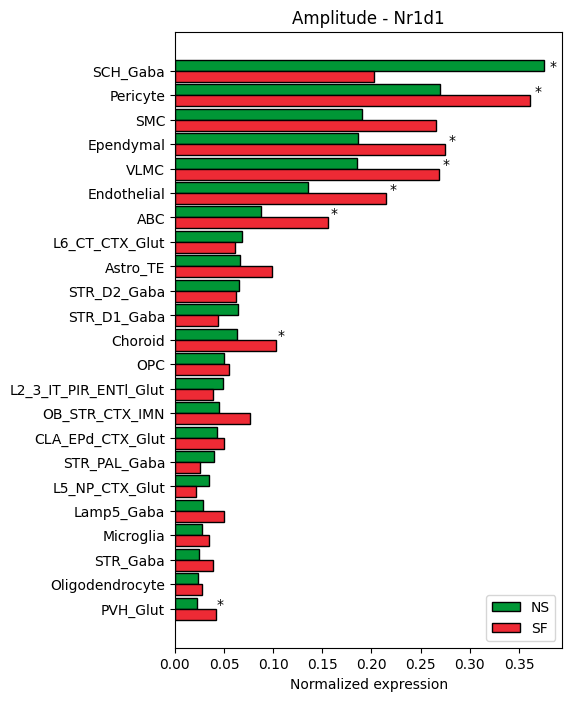

In [262]:
## Amplitude
from module.misc import genes_list

clockgeneslist = genes_list('clock')
gene = 'Nr1d1'

temp_SF = []
temp_NS = []
stat = []
temp_cell = []

for cell in dict_all_cycling.keys():
    if dict_all_cycling[cell]['CircaCompare']['gene'].isin([gene]).sum() != 0:
        temp_SF.append(dict_all_cycling[cell]['CircaCompare'].loc[gene,'SD1 amplitude estimate'])
        temp_NS.append(dict_all_cycling[cell]['CircaCompare'].loc[gene,'circa4 amplitude estimate'])
        stat.append(dict_all_cycling[cell]['CircaCompare'].loc[gene,'P-value for amplitude difference'])
        temp_cell.append(cell)
    else:
        continue
df_amp = pd.DataFrame(data= {"NS" : temp_NS, "SF": temp_SF, "stat":stat},index = temp_cell)

df_amp.sort_values(by="NS", ascending =False, inplace = True)
# df_amp.sort_index(ascending = False,inplace= True)

plt.figure(figsize= (5,8))
plt.barh(y= df_amp.index, width = df_amp['NS'], height = -0.45, label = "NS", align = "edge", edgecolor = 'black')
plt.barh(y= df_amp.index, width = df_amp['SF'], height = 0.45, align = "edge", label = "SF", edgecolor = 'black')

for idx, stat in enumerate(df_amp['stat']):
    if stat <= 0.05:
        max_ = max(df_amp['NS'][idx], df_amp['SF'][idx])
        plt.text(y= df_amp.index[idx], x = max_ *1.015, s = "*")

plt.gca().invert_yaxis()
plt.legend()
plt.title(f'Amplitude - {gene}')
plt.xlabel('Normalized expression')
# plt.xticks(rotation = 90)

/tmp/ipykernel_50331/2653438566.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_ = max(df_amp['NS'][idx], df_amp['SF'][idx])


Text(0.5, 0, 'Normalized expression')

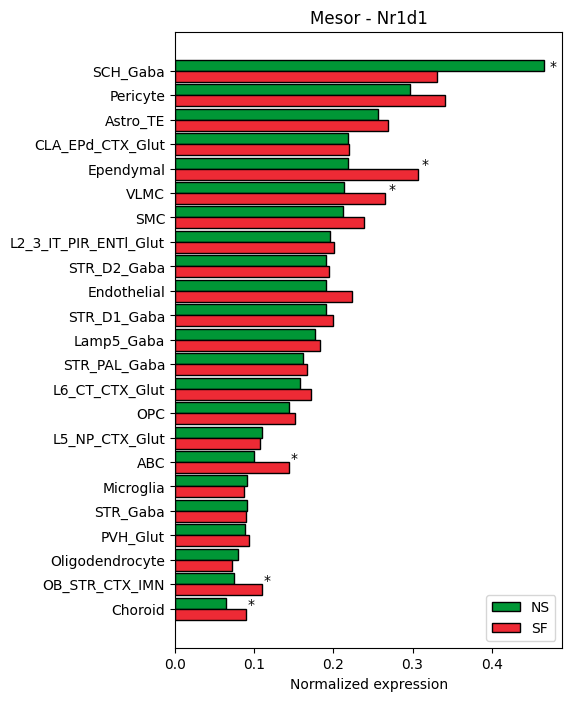

In [265]:
## MESOR
from module.misc import genes_list

clockgeneslist = genes_list('clock')
gene = 'Nr1d1'

temp_SF = []
temp_NS = []
stat = []
temp_cell = []

for cell in dict_all_cycling.keys():
    if dict_all_cycling[cell]['CircaCompare']['gene'].isin([gene]).sum() != 0:
        temp_SF.append(dict_all_cycling[cell]['CircaCompare'].loc[gene,'SD1 mesor estimate'])
        temp_NS.append(dict_all_cycling[cell]['CircaCompare'].loc[gene,'circa4 mesor estimate'])
        stat.append(dict_all_cycling[cell]['CircaCompare'].loc[gene,'P-value for mesor difference'])
        temp_cell.append(cell)
    else:
        continue
df_amp = pd.DataFrame(data= {"NS" : temp_NS, "SF": temp_SF, "stat" : stat},index = temp_cell)

df_amp.sort_values(by="NS", ascending =False, inplace = True)
# df_amp.sort_index(ascending = False,inplace= True)

plt.figure(figsize= (5,8))
plt.barh(y= df_amp.index, width = df_amp['NS'], height = -0.45, label = "NS", align = "edge", edgecolor = 'black')
plt.barh(y= df_amp.index, width = df_amp['SF'], height = 0.45, align = "edge", label = "SF", edgecolor = 'black')

for idx, stat in enumerate(df_amp['stat']):
    if stat <= 0.05:
        max_ = max(df_amp['NS'][idx], df_amp['SF'][idx])
        plt.text(y= df_amp.index[idx], x = max_ * 1.015, s = "*")

plt.gca().invert_yaxis()
plt.legend()
plt.title(f'Mesor - {gene}')
plt.xlabel('Normalized expression')

In [269]:
df2 = df[clockgeneslist]

In [270]:
df2['cell_type_final'] = df['cell_type_final']

/tmp/ipykernel_50331/3691368173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['cell_type_final'] = df['cell_type_final']


In [272]:
df2 = df2[df2['cell_type_final']=="SCH Gaba"]

In [277]:
df2.drop('cell_type_final', axis = 1, inplace = True)

/tmp/ipykernel_50331/3682353299.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop('cell_type_final', axis = 1, inplace = True)


In [279]:
df2

,Arntl,Clock,Cry1,Cry2,Nr1d1,Per1,Per2,Per3,Rora,Rorb,Rorc,Npas2
circa4-IGM-ZT01_aabpfggb-1,0.000000,0.429028,0.0,0.0,1.145195,1.145195,0.0,0.429028,0.958311,0.958311,0.0,0.000000
circa4-IGM-ZT01_aacbbpfe-1,0.516889,0.516889,0.0,0.0,1.108697,0.516889,0.0,0.000000,0.516889,1.108697,0.0,0.000000
circa4-IGM-ZT01_aacbnonh-1,0.000000,0.000000,0.0,0.0,1.361773,1.076845,0.0,0.000000,0.000000,0.000000,0.0,0.000000
circa4-IGM-ZT01_aaejfeod-1,0.000000,0.000000,0.0,0.0,1.635617,0.000000,0.0,0.000000,0.000000,1.120476,0.0,0.000000
circa4-IGM-ZT01_aaeldocb-1,0.000000,0.000000,0.0,0.0,0.889792,0.889792,0.0,0.000000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
SD1-ZT21_nkohciom-1,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000
SD1-ZT21_nlahbjlh-1,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,1.492208,0.000000,0.0,0.000000
SD1-ZT21_ocojeedm-1,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000
SD1-ZT21_ocpealof-1,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.538431
